### Load Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data

In [36]:
df=pd.read_csv("/content/bitcoin_price.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


# Time Series Index

In [37]:
df['Date']=pd.to_datetime(df['Date'],format='%Y-%m-%d')
df.set_index('Date',inplace=True)
df.head(7)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600
2014-09-23,402.092010,441.557007,396.196991,435.790985,435.790985,45099500


In [38]:
df.shape

(3392, 6)

In [39]:
# Resampling to Weekly Frequency and calculate mean values
df.resample('W').mean()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-21,429.916998,437.718195,406.624402,416.859003,416.859003,3.138068e+07
2014-09-28,410.650718,418.668993,399.377141,407.692566,407.692566,2.668180e+07
2014-10-05,369.774288,376.721000,353.207140,361.426570,361.426570,3.952256e+07
2014-10-12,346.927429,363.308864,337.567858,355.234580,355.234580,4.873611e+07
2014-10-19,389.010284,397.790427,380.410575,390.479854,390.479854,2.241458e+07
...,...,...,...,...,...,...
2023-12-03,38038.414062,38743.479353,37766.444196,38399.994978,38399.994978,1.919430e+10
2023-12-10,43002.227121,44027.167411,42586.383929,43538.877232,43538.877232,2.692909e+10
2023-12-17,42369.368862,42969.940848,41148.103237,42020.472656,42020.472656,2.407050e+10


In [40]:
df.resample('ME').mean()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-30,412.654003,421.104422,398.174641,407.182428,407.182428,2.934864e+07
2014-10-31,365.748000,374.314260,354.856645,364.148873,364.148873,2.912885e+07
2014-11-30,364.850235,376.494235,357.241831,366.099799,366.099799,2.199111e+07
2014-12-31,343.074836,347.487129,336.565775,341.267871,341.267871,1.784201e+07
2015-01-31,251.799905,261.391583,240.495550,248.782547,248.782547,3.544555e+07
...,...,...,...,...,...,...
2023-08-31,27959.756615,28204.527722,27517.854587,27852.792843,27852.792843,1.412013e+10
2023-09-30,26271.268229,26573.941862,26041.182292,26306.136393,26306.136393,1.125458e+10
2023-10-31,29511.811114,30155.900454,29235.543977,29755.895161,29755.895161,1.536857e+10


#Exploring Data

## Rolling

Series.rolling() - create a rolling window calculation, to smooth time-series data and identify trends over time

`Rolling(7).mean()` means look at last 7 days and compute their mean

```
Day:      1    2    3    4    5    6    7    8    9
Value:   10   20   30   40   50   60   70   80   90
Rolling: NaN  NaN  NaN  NaN  NaN  NaN  40   50   60
```
at day 1-6, not enough data so output is NaN

at day 7

`(10 + 20 + 30 + 40 + 50 + 60 + 70) / 7 = 40`

Similary calculate for others day


In [41]:
df['7_day_rolling']=df['Close'].rolling(window=7).mean()

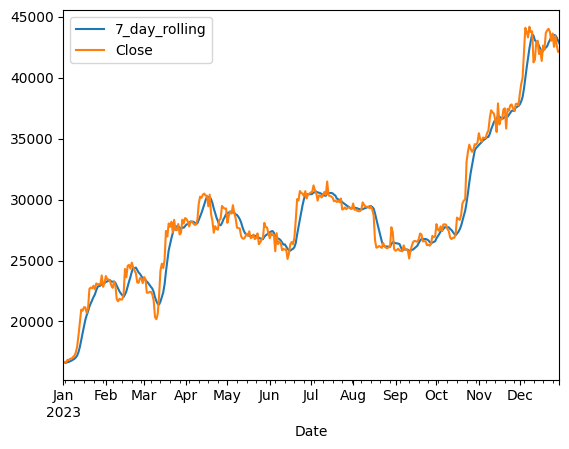

In [42]:
df[['7_day_rolling','Close']].loc['2023'].plot()
plt.show()

In [43]:
df['Close'].max()

67566.828125

In [44]:
df['Close'].idxmax()

Timestamp('2021-11-08 00:00:00')

**Find out the month of highest closing average**

In [45]:
df.resample('ME').mean()['Close'].idxmax()

Timestamp('2021-11-30 00:00:00')

## daily returns

Daily return means: how much the price changed from yesterday to today (in percentage).

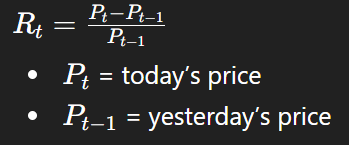

`pct_change()` the directly computes the daily returns



In [46]:
df['daily_returns']=df['Close'].pct_change()*100

**Days with more than 10% change in closing price**

In [47]:
df[abs(df['daily_returns'])>10].head()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling,daily_returns
Date,,,,,,,,
2014-11-12,367.984985,429.717987,367.984985,423.561005,423.561005,45783200,365.519579,15.193570
2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400,310.171718,-10.776686
2015-01-13,267.394012,268.277008,219.906006,225.860992,225.860992,72843904,271.743853,-15.659308
2015-01-14,223.893997,223.893997,171.509995,178.102997,178.102997,97638704,255.138994,-21.144862
2015-01-15,176.897003,229.067001,176.897003,209.843994,209.843994,81773504,244.638280,17.821709


# Data Visulization

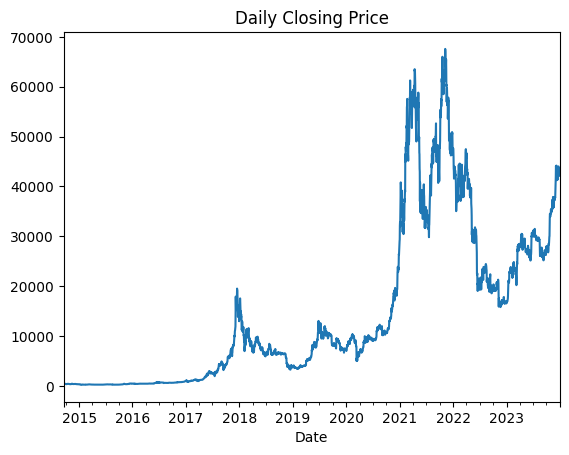

In [48]:
#daily closing price plot
df['Close'].plot(title='Daily Closing Price')
plt.show()

/tmp/ipykernel_2523/2161552341.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample('Y').sum()['Volume'].plot(title='Yearly Volume')


<Axes: title={'center': 'Yearly Volume'}, xlabel='Date'>

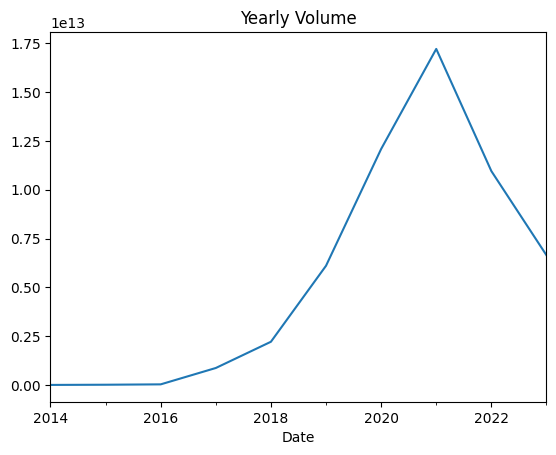

In [49]:
# Plot the yearly volume
df.resample('Y').sum()['Volume'].plot(title='Yearly Volume')

In [50]:
# Create a new column for 30- Day rolling average of the volume
df['30_day_rolling_vol']=df['Volume'].rolling(window=30).mean()

<Axes: >

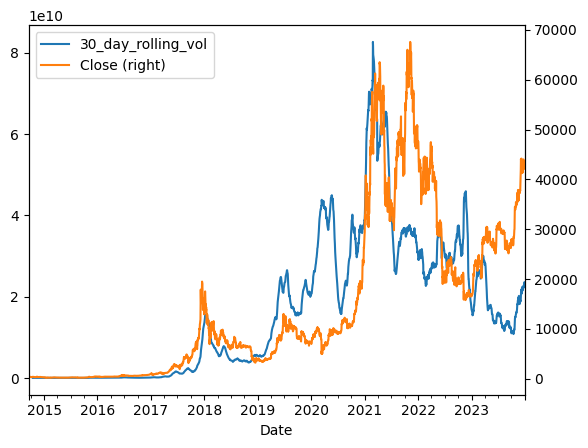

In [51]:
df['30_day_rolling_vol'].plot(legend=True)
df['Close'].plot(secondary_y=True,legend=True)

In [52]:
df[['Close','30_day_rolling_vol']].corr()

,Close,30_day_rolling_vol
Close,1.000000,0.750445
30_day_rolling_vol,0.750445,1.000000


# Data Manupulation

In [53]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
7_day_rolling,6
daily_returns,1
30_day_rolling_vol,29


In [54]:
df['30_day_rolling_vol'].fillna(method='bfill',inplace=True)

/tmp/ipykernel_2523/3953771599.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['30_day_rolling_vol'].fillna(method='bfill',inplace=True)


In [55]:
df['7_day_rolling'].interpolate(inplace=True)

/tmp/ipykernel_2523/2889037167.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['7_day_rolling'].interpolate(inplace=True)


In [56]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
7_day_rolling,6
daily_returns,1
30_day_rolling_vol,0


#Extract Time Variable

In [57]:
df.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq=None)

In [58]:
df['year']=df.index.year
df['month']=df.index.month
df['day']=df.index.day
df['weekday']=df.index.day_name()
df['weekeday_numeric']=df.index.weekday
df['is_weekend']=df.index.weekday>4
df.head()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling,daily_returns,30_day_rolling_vol,year,month,day,weekday,weekeday_numeric,is_weekend
Date,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN,3.624856e+07,2014,9,17,Wednesday,2,False
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558,3.624856e+07,2014,9,18,Thursday,3,False
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,NaN,-6.984265,3.624856e+07,2014,9,19,Friday,4,False
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,NaN,3.573492,3.624856e+07,2014,9,20,Saturday,5,True
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,NaN,-2.465854,3.624856e+07,2014,9,21,Sunday,6,True


#Lagged Values

Series.shift(1) - each value is moved to the row below its current position
Purpose on stock price prediction: Using yesterday's price to help predict today's


In [59]:
df['closed_lag1']=df['Close'].shift(1)
df['closed_lag2']=df['Close'].shift(2)

In [60]:
df[['Close','closed_lag1','closed_lag2']]

,Close,closed_lag1,closed_lag2
Date,,,
2014-09-17,457.334015,NaN,NaN
2014-09-18,424.440002,457.334015,NaN
2014-09-19,394.795990,424.440002,457.334015
2014-09-20,408.903992,394.795990,424.440002
2014-09-21,398.821014,408.903992,394.795990
...,...,...,...
2023-12-26,42520.402344,43613.140625,43016.117188
2023-12-27,43442.855469,42520.402344,43613.140625
2023-12-28,42627.855469,43442.855469,42520.402344


# Seasonality

In [61]:
from statsmodels.graphics.tsaplots import month_plot,quarter_plot

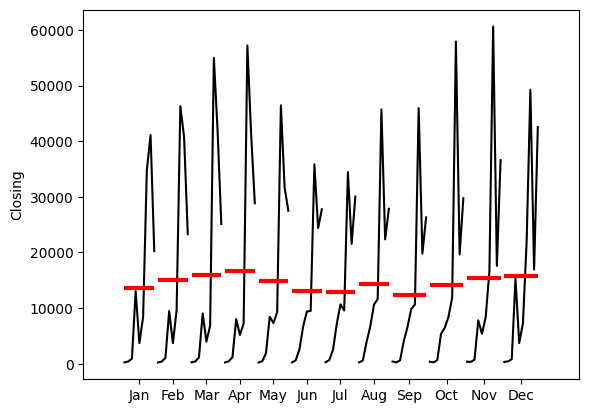

In [62]:
month_plot(df['Close'].resample('ME').mean(),
           ylabel='Closing')
plt.show()

* The red lines are slightly higher in March, April, and May. This suggests that, historically, the price tends to be a bit better in the spring
* The red lines drop in June and July. This suggests a mid-year "slump" where prices are usually lower.
* The red lines start climbing again from October to December
---
- Best buying time in June,July and September. Because red lines(avg cost) are at their lowest
- Best selling time April ,Nov or December ,because red lines(avg cost) sits in the highest

/tmp/ipykernel_2523/3813174700.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df.resample('Q')['Close'].mean(),


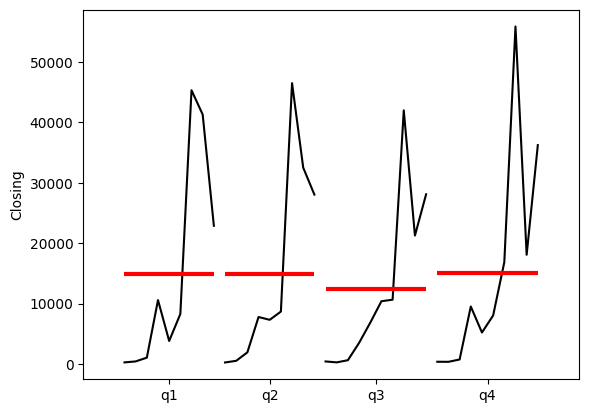

In [63]:
quarter_plot(df.resample('Q')['Close'].mean(),
             ylabel='Closing')
plt.show()

In [64]:
# Load data of chocolate monthly revenue
df_choco = pd.read_csv("choco_monthly_revenue.csv", index_col = 0, parse_dates = True)
df_choco.head()

,revenue
Month with Year,
2018-01-01,1458
2018-02-01,1102
2018-03-01,1584
2018-04-01,1676
2018-05-01,1461


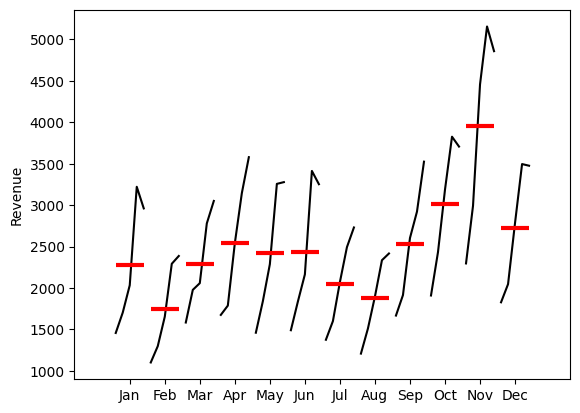

In [65]:
month_plot(df_choco['revenue'],
           ylabel='Revenue')
plt.show()

<Axes: xlabel='Month with Year'>

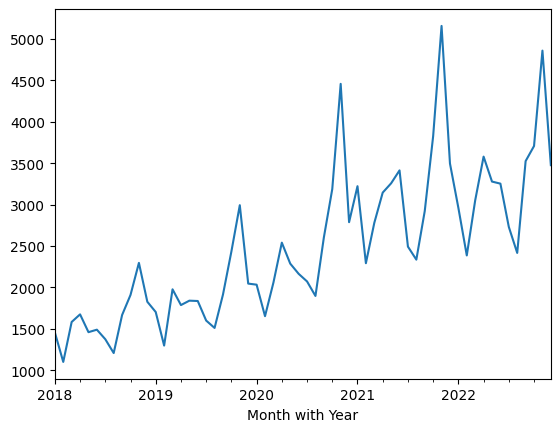

In [66]:
df_choco['revenue'].plot()

## Seasonal Decompose

`seasonal_decompose` - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

- Trend: The overall direction of the series (increasing, decreasing, or stable).
- Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
- Residual: The remaining variation after removing trend and seasonal components.

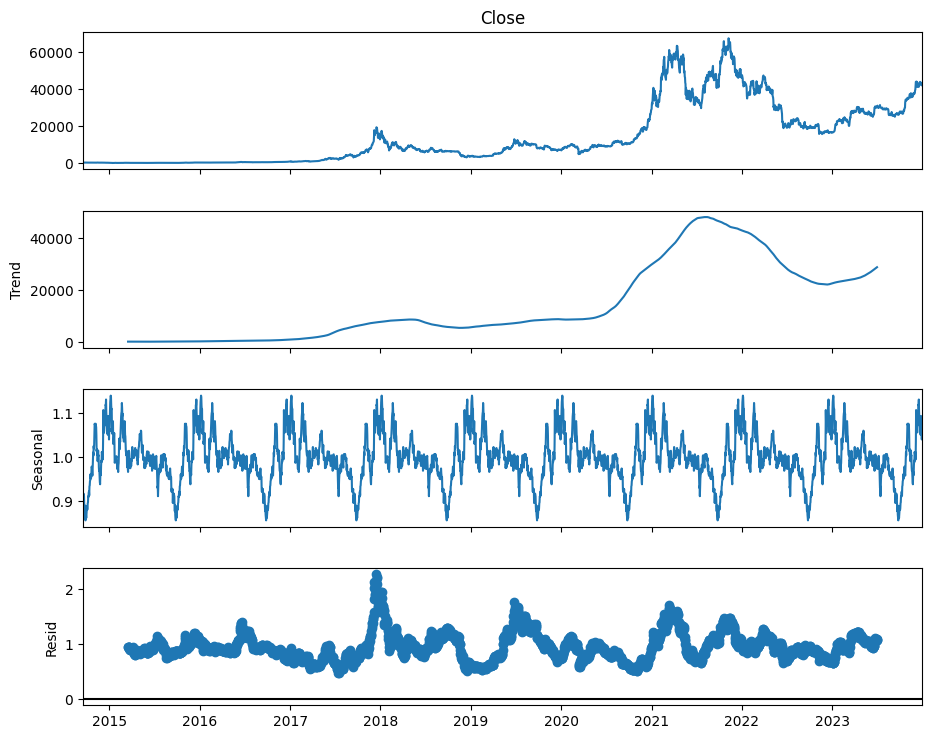

In [67]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df['Close'],
                                 model='mul',
                                 period=365)
fig=decomposition.plot()
fig.set_size_inches(10,8)

for chocodf

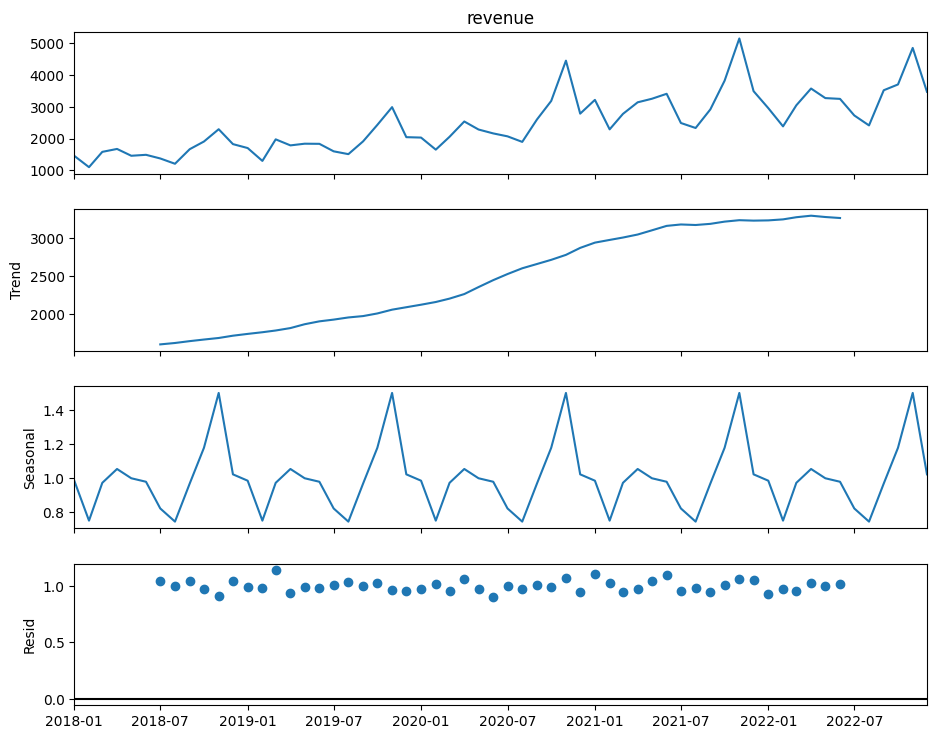

In [68]:
decomposition = seasonal_decompose(df_choco['revenue'],
                                   model = 'mul',
                                   period = 12)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

# ACF & PACF

In [70]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

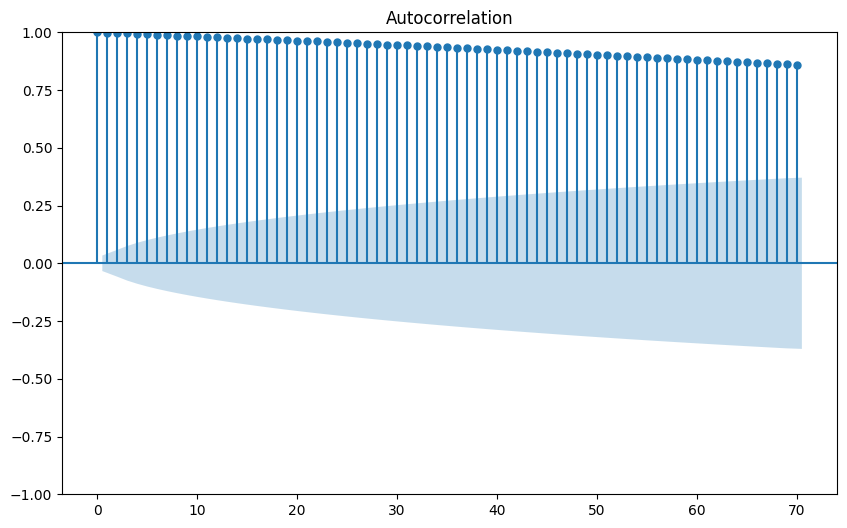

In [76]:
# plot autocorrelation(ACF) of the bitcoin closing values|
fig,ax=plt.subplots(figsize=(10,6))
plot_acf(df['Close'],lags=70,ax=ax)
plt.show()

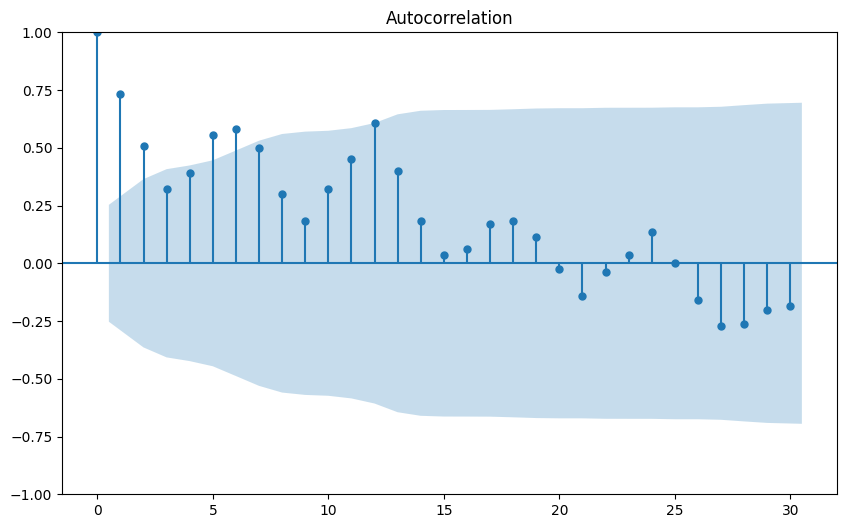

In [77]:
# plot acf of chocolate revenue values
fig,ax=plt.subplots(figsize=(10,6))
plot_acf(df_choco['revenue'],lags=30,ax=ax)
plt.show()

pacf

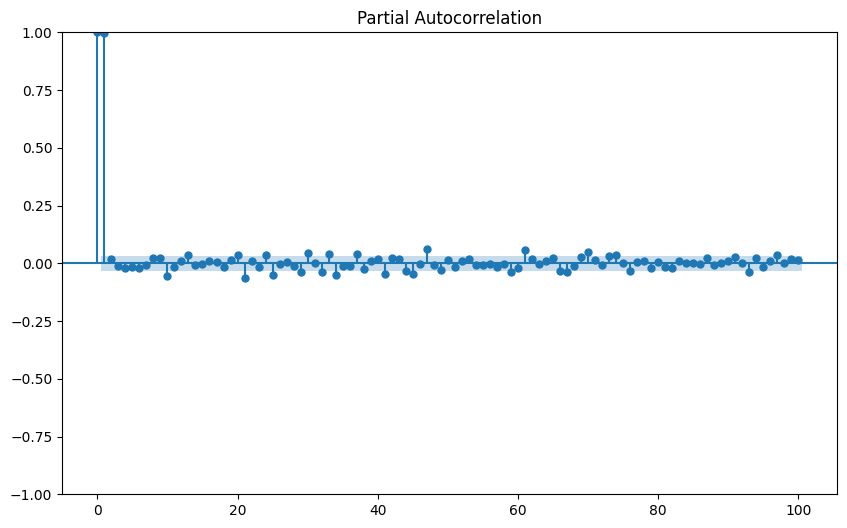

In [78]:
# Plot the partial autocorrelation (PACF) of the bitcoin closing values
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df['Close'], lags = 100, ax = ax)
plt.show()

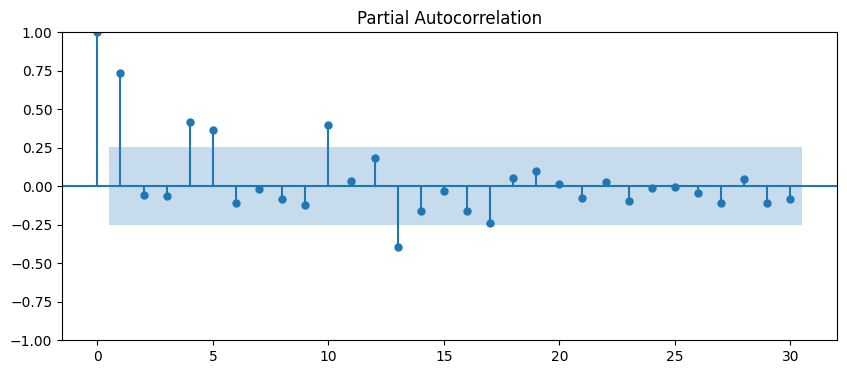

In [79]:
# Plot the partial autocorrelation (PACF) of the chocolate revenue values
fig, ax = plt.subplots(figsize = (10,4))
plot_pacf(df_choco['revenue'], lags = 30, ax = ax)
plt.show()

<Axes: xlabel='Month with Year'>

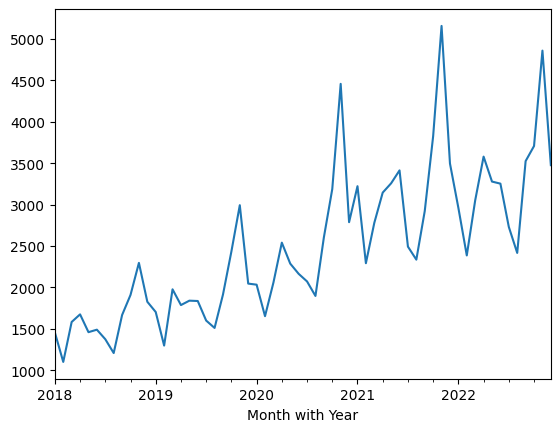

In [80]:
df_choco['revenue'].plot()